# Omizunagidori Accelerometer Data — Statistics Analysis

**Dataset**: Streaked shearwater (omizunagidori) behavior classification using tri-axial accelerometer  
**Data source**: `data/omizunagidori/raw/omizunagidori_{year}.npy` (2018, 2020, 2021, 2022)  
**Windowed cache**: `data/omizunagidori/data.npy` / `data/omizunagidori/label.npy` (auto-generated)

**Label names**:
| ID | Behavior |
|----|----------|
| 0  | stationary |
| 1  | preening |
| 2  | bathing |
| 3  | flight_take_off |
| 4  | flight_cruising |
| 5  | foraging_dive |
| 6  | surface_seizing |
| 7  | body_shaking |

## 0. Imports & Configuration

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_palette('tab10')

NOTEBOOK_DIR = os.path.abspath('')
DATA_DIR     = os.path.join(NOTEBOOK_DIR, '..', '..', 'data', 'omizunagidori')
NPY_DATA     = os.path.join(DATA_DIR, 'data.npy')
NPY_LABEL    = os.path.join(DATA_DIR, 'label.npy')
FIG_DIR      = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

LABEL_NAMES = {
    0: 'stationary', 1: 'preening', 2: 'bathing',
    3: 'flight_take_off', 4: 'flight_cruising',
    5: 'foraging_dive', 6: 'surface_seizing', 7: 'body_shaking',
}
AXES        = ['acc_x', 'acc_y', 'acc_z']
COLORS      = plt.cm.tab10(np.linspace(0, 1, 10))
SAMPLE_RATE = 25   # Hz
WINDOW_SIZE = 50   # timesteps = 2 sec
YEARS       = [2018, 2020, 2021, 2022]

print('npy  :', NPY_DATA)
print('figs :', FIG_DIR)

npy  : /Users/cassie/Documents/code/DeepView/analysis/omizunagidori/../../data/omizunagidori/data.npy
figs : /Users/cassie/Documents/code/DeepView/analysis/omizunagidori/figures


## 1. Preprocessing: Raw npy → Windowed npy

Pipeline:
1. Load `labeled_data` from each year, concatenate
2. Drop `label_id == -2` (unknown)
3. Z-score normalize acc_x/y/z globally
4. Sliding window (size=50, step=50, non-overlapping)
5. Save `data.npy` shape `(N, 3, 50)` and `label.npy` shape `(N, 50)`

In [3]:
def sliding_window(data_np, len_sw, step):
    windows = []
    for idx in range(0, data_np.shape[0] - len_sw - step, step):
        windows.append(data_np[idx: idx + len_sw, :])
    windows.append(data_np[-1 - len_sw: -1, :])
    return np.stack(windows, axis=0)


def build_windowed_npy(data_dir, npy_data_path, npy_label_path,
                       len_sw=50, step=50):
    dfs = []
    for yr in YEARS:
        path = os.path.join(data_dir, 'raw', f'omizunagidori_{yr}.npy')
        if not os.path.exists(path):
            print(f'  Missing: {path}')
            continue
        d  = np.load(path, allow_pickle=True).item()
        ld = d['labeled_data'].copy()
        ld['year'] = yr
        dfs.append(ld)
    df = pd.concat(dfs, ignore_index=True)
    print(f'Total labeled rows: {len(df):,}')

    df = df[df['label_id'] != -2].copy()
    df['label_id'] = df['label_id'].astype(int)
    print(f'After removing unknown: {len(df):,}')

    acc = df[AXES].values.astype(float)
    mean_v = acc.mean(axis=0)
    std_v  = np.maximum(acc.std(axis=0), 1e-5)
    df[AXES] = (acc - mean_v) / std_v

    selected_np = df[AXES + ['label_id']].values
    print('Applying sliding window ...')
    windows = sliding_window(selected_np, len_sw, step)

    data_b  = np.transpose(windows[:, :, :3], (0, 2, 1))
    label_b = windows[:, :, 3]

    np.save(npy_data_path, data_b)
    np.save(npy_label_path, label_b)
    print(f'Saved data.npy  : {data_b.shape}')
    print(f'Saved label.npy : {label_b.shape}')
    return data_b, label_b


if os.path.exists(NPY_DATA) and os.path.exists(NPY_LABEL):
    print('Loading cached npy ...')
    X = np.load(NPY_DATA)
    Y = np.load(NPY_LABEL)
else:
    X, Y = build_windowed_npy(DATA_DIR, NPY_DATA, NPY_LABEL)

y = Y[:, 0].astype(int)
labels_to_analyze = sorted(np.unique(y))
class_names       = [LABEL_NAMES.get(l, str(l)) for l in labels_to_analyze]

print(f'X shape       : {X.shape}')
print(f'Unique labels : {labels_to_analyze}')
print(f'Label counts  : {dict(sorted(Counter(y).items()))}')

Total labeled rows: 3,277,415
After removing unknown: 1,093,401
Applying sliding window ...
Saved data.npy  : (21868, 3, 50)
Saved label.npy : (21868, 50)
X shape       : (21868, 3, 50)
Unique labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Label counts  : {np.int64(0): 9305, np.int64(1): 301, np.int64(2): 521, np.int64(3): 111, np.int64(4): 10920, np.int64(5): 404, np.int64(6): 304, np.int64(7): 2}


In [ ]:
dfs_raw = []
for yr in YEARS:
    path = os.path.join(DATA_DIR, 'raw', f'omizunagidori_{yr}.npy')
    if not os.path.exists(path): continue
    d = np.load(path, allow_pickle=True).item()
    ld = d['labeled_data'].copy()
    ld['year'] = yr
    dfs_raw.append(ld)
df_all = pd.concat(dfs_raw, ignore_index=True)

df_known = df_all[df_all['label_id'] != -2].copy()
df_known['label_id'] = df_known['label_id'].astype(int)

# 计算每个class的数据总长度和连续超过50个点的统计
results = []

for label in labels_to_analyze:
    mask = df_known['label_id'] == label
    df_cls = df_known[mask].copy()
    
    # 总长度（行数）
    total_length = len(df_cls)
    
    # 计算连续超过50个点的段
    y_cls = df_cls['label_id'].values
    
    # 识别连续段
    continuous_segments = []
    start_idx = 0
    
    for i in range(len(y_cls)):
        if i == len(y_cls) - 1 or y_cls[i] != y_cls[i + 1]:
            segment_length = i - start_idx + 1
            if segment_length >= 50:
                continuous_segments.append(segment_length)
            if i < len(y_cls) - 1:
                start_idx = i + 1
    
    # 统计
    num_segments = len(continuous_segments)
    total_segment_length = sum(continuous_segments)
    avg_segment_length = total_segment_length / num_segments if num_segments > 0 else 0
    
    results.append({
        'label': label,
        'behavior': LABEL_NAMES.get(label, str(label)),
        'total_length': total_length,
        'num_segments_≥50': num_segments,
        'total_segment_length': total_segment_length,
        'avg_segment_length': round(avg_segment_length, 2),
        'coverage_%': round(total_segment_length / total_length * 100, 2) if total_length > 0 else 0,
    })

result_df = pd.DataFrame(results)
print('=== Per-class Data Length & Continuous Segments (≥50 points) ===')
print(result_df.to_string(index=False))
print()
print(f'Total samples across all classes: {result_df["total_length"].sum():,}')
print(f'Total samples in segments ≥50: {result_df["total_segment_length"].sum():,}')

=== Per-class Data Length & Continuous Segments (≥50 points) ===
 label        behavior  total_length  num_segments_≥50  total_segment_length  avg_segment_length  coverage_%
     0      stationary        465081                 1                465081            465081.0       100.0
     1        preening         15162                 1                 15162             15162.0       100.0
     2         bathing         26034                 1                 26034             26034.0       100.0
     3 flight_take_off          5472                 1                  5472              5472.0       100.0
     4 flight_cruising        545810                 1                545810            545810.0       100.0
     5   foraging_dive         20289                 1                 20289             20289.0       100.0
     6 surface_seizing         15470                 1                 15470             15470.0       100.0
     7    body_shaking            83                 1         

## 2. Class Distribution

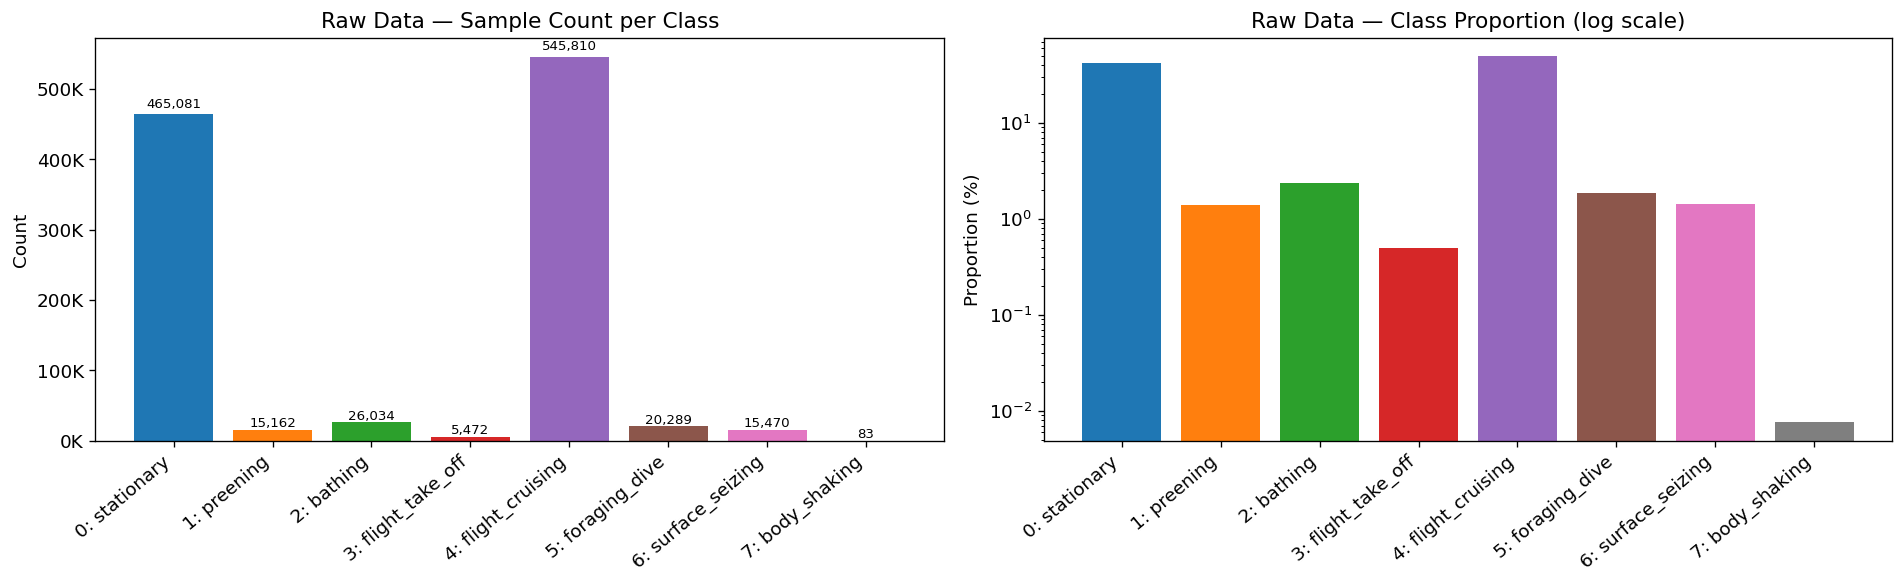

In [ ]:
# 2.1 Per-year raw row counts
# dfs_raw = []
# for yr in YEARS:
#     path = os.path.join(DATA_DIR, 'raw', f'omizunagidori_{yr}.npy')
#     if not os.path.exists(path): continue
#     d = np.load(path, allow_pickle=True).item()
#     ld = d['labeled_data'].copy()
#     ld['year'] = yr
#     dfs_raw.append(ld)
# df_all = pd.concat(dfs_raw, ignore_index=True)

# df_known = df_all[df_all['label_id'] != -2].copy()
# df_known['label_id'] = df_known['label_id'].astype(int)
label_counts_raw = df_known.groupby('label_id').size()
label_counts_raw.index = [f"{i}: {LABEL_NAMES.get(i,'?')}" for i in label_counts_raw.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
bars = ax.bar(range(len(label_counts_raw)), label_counts_raw.values,
              color=COLORS[:len(label_counts_raw)])
ax.set_xticks(range(len(label_counts_raw)))
ax.set_xticklabels(label_counts_raw.index, rotation=40, ha='right')
ax.set_title('Raw Data — Sample Count per Class')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, v in zip(bars, label_counts_raw.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
props = label_counts_raw.values / label_counts_raw.values.sum() * 100
ax.bar(range(len(label_counts_raw)), props, color=COLORS[:len(label_counts_raw)])
ax.set_xticks(range(len(label_counts_raw)))
ax.set_xticklabels(label_counts_raw.index, rotation=40, ha='right')
ax.set_yscale('log')
ax.set_title('Raw Data — Class Proportion (log scale)')
ax.set_ylabel('Proportion (%)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_raw.png'), bbox_inches='tight')
plt.show()

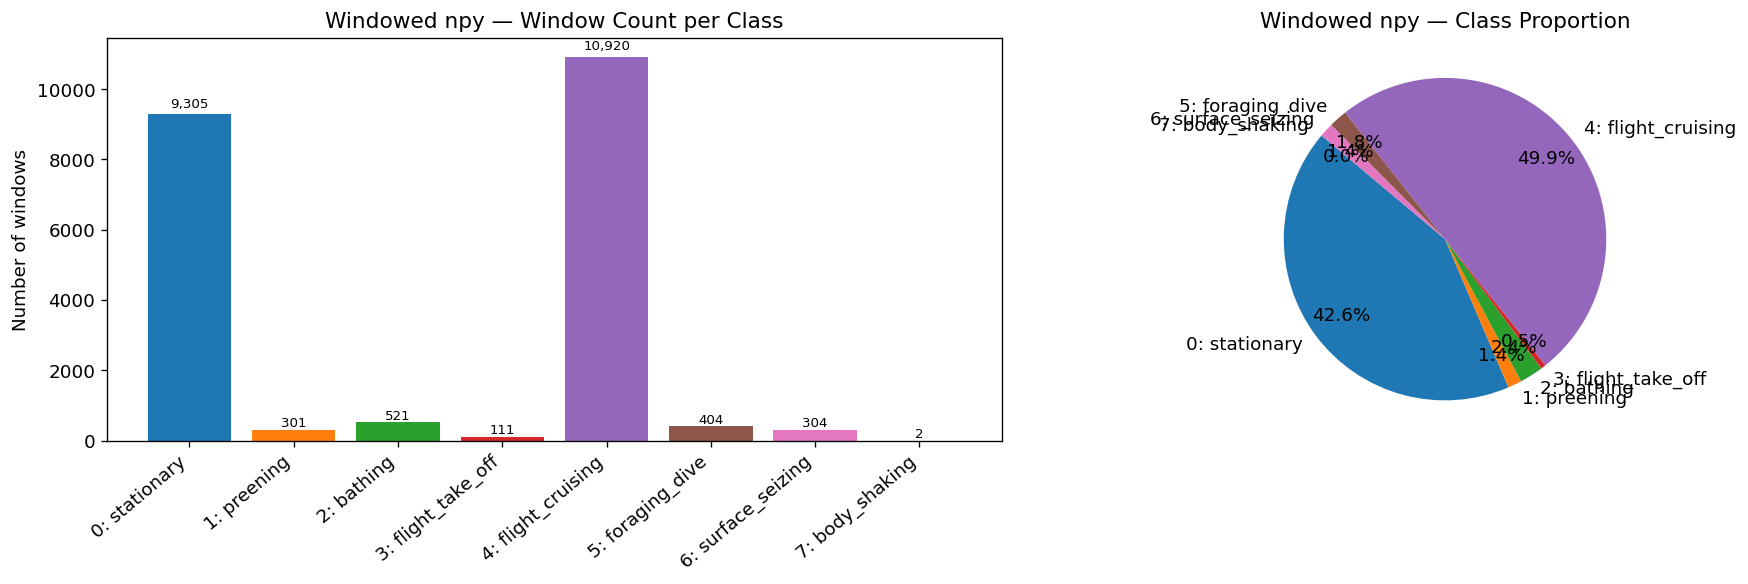

In [5]:
# 2.2 Windowed npy class counts
cnt    = Counter(y)
counts = [cnt.get(l, 0) for l in labels_to_analyze]
props  = np.array(counts) / sum(counts) * 100
names  = [f"{l}: {LABEL_NAMES.get(l,'?')}" for l in labels_to_analyze]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
bars = ax.bar(range(len(labels_to_analyze)), counts, color=COLORS[:len(labels_to_analyze)])
ax.set_xticks(range(len(labels_to_analyze)))
ax.set_xticklabels(names, rotation=40, ha='right')
ax.set_title('Windowed npy — Window Count per Class')
ax.set_ylabel('Number of windows')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.pie(props, labels=names, autopct='%1.1f%%', colors=COLORS[:len(labels_to_analyze)],
       startangle=140, pctdistance=0.8)
ax.set_title('Windowed npy — Class Proportion')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_npy.png'), bbox_inches='tight')
plt.show()

In [6]:
# 2.3 Class imbalance metrics
p           = np.array(counts) / sum(counts)
entropy     = -np.sum(p * np.log2(p + 1e-12))
max_entropy = np.log2(len(p))
gini        = 1 - np.sum(p**2)
ir          = max(p) / min(p)
eff_classes = np.exp(entropy)

print('=== Class Imbalance Metrics ===')
print(f'  Classes          : {len(p)}')
print(f'  Shannon entropy  : {entropy:.4f}  (max = {max_entropy:.4f})')
print(f'  Normalized entropy: {entropy/max_entropy:.4f}')
print(f'  Gini impurity    : {gini:.4f}')
print(f'  Imbalance ratio  : {ir:.1f}x')
print(f'  Effective classes: {eff_classes:.2f}')
print()
for label_id, pi in zip(labels_to_analyze, p):
    w = (1/pi) / np.sum(1/p)
    print(f'  {label_id:2d} {LABEL_NAMES.get(label_id,"?"):<20} p={pi:.4f}  weight={w:.4f}')

=== Class Imbalance Metrics ===
  Classes          : 8
  Shannon entropy  : 1.4704  (max = 3.0000)
  Normalized entropy: 0.4901
  Gini impurity    : 0.5683
  Imbalance ratio  : 5460.0x
  Effective classes: 4.35

   0 stationary           p=0.4255  weight=0.0002
   1 preening             p=0.0138  weight=0.0064
   2 bathing              p=0.0238  weight=0.0037
   3 flight_take_off      p=0.0051  weight=0.0173
   4 flight_cruising      p=0.4994  weight=0.0002
   5 foraging_dive        p=0.0185  weight=0.0048
   6 surface_seizing      p=0.0139  weight=0.0063
   7 body_shaking         p=0.0001  weight=0.9611


## 3. Per-Year & Per-Individual Analysis

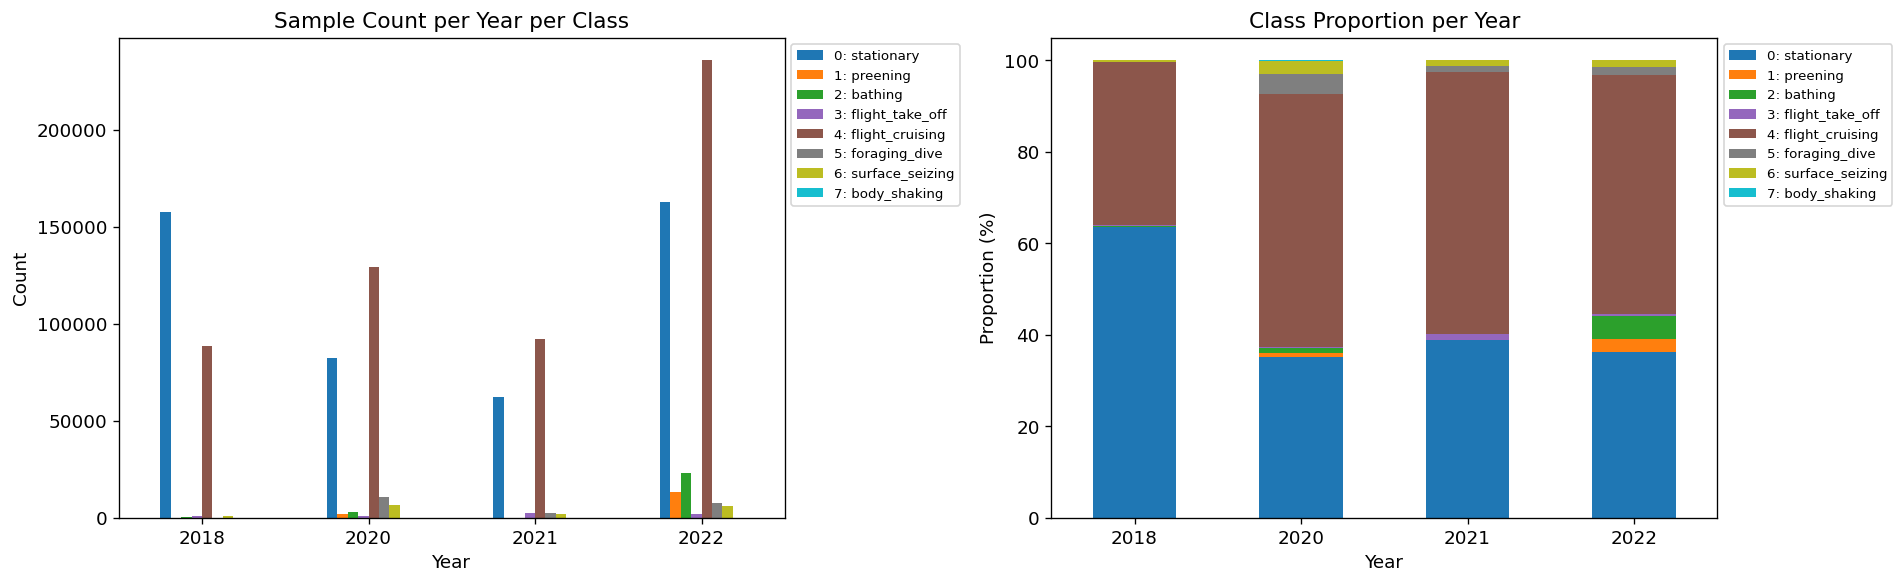

In [7]:
# Per-year label distribution
year_label = df_known.groupby(['year', 'label_id']).size().unstack(fill_value=0)
year_label.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c),'?')}" for c in year_label.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
year_label.plot(kind='bar', ax=ax, colormap='tab10', stacked=False)
ax.set_title('Sample Count per Year per Class')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xticklabels(year_label.index, rotation=0)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

ax = axes[1]
year_norm = year_label.div(year_label.sum(axis=1), axis=0) * 100
year_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion (%)')
ax.set_xticklabels(year_label.index, rotation=0)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_year.png'), bbox_inches='tight')
plt.show()

Individuals (n=27): ['20MZ01_20200826', '20MZ03_20200909', '20MZ09_20201005', '9B34075', '9B36347', '9B36360', '9B36365', '9B36547', '9B36577', '9B36578', 'LB01', 'LB02', 'LB03', 'LB04', 'LB05', 'LB08', 'LB09', 'LB11', 'LB13', 'LB14', 'LB15', 'LB17', 'LOB01', 'LOB02', 'LOB03', 'UNK001_20200914', 'UNK003_20200901']


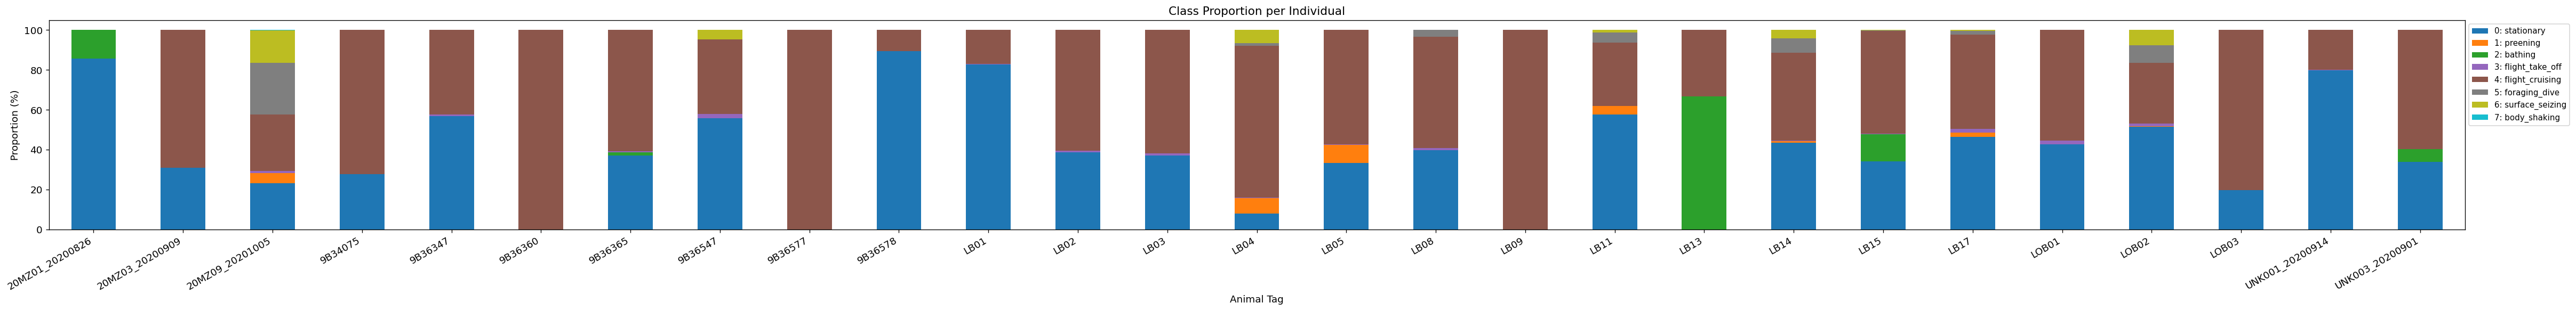


Recording duration per individual (hours):
  20MZ01_20200826: total=0.13h  labeled=0.13h
  20MZ03_20200909: total=1.69h  labeled=1.69h
  20MZ09_20201005: total=0.58h  labeled=0.45h
  9B34075: total=0.49h  labeled=0.48h
  9B36347: total=0.41h  labeled=0.41h
  9B36360: total=0.08h  labeled=0.08h
  9B36365: total=0.16h  labeled=0.16h
  9B36547: total=0.16h  labeled=0.15h
  9B36577: total=0.41h  labeled=0.08h
  9B36578: total=1.39h  labeled=1.39h
  LB01: total=0.41h  labeled=0.41h
  LB02: total=0.41h  labeled=0.30h
  LB03: total=0.08h  labeled=0.08h
  LB04: total=0.75h  labeled=0.72h
  LB05: total=0.50h  labeled=0.50h
  LB08: total=0.55h  labeled=0.36h
  LB09: total=0.50h  labeled=0.33h
  LB11: total=1.01h  labeled=0.79h
  LB13: total=0.27h  labeled=0.25h
  LB14: total=0.20h  labeled=0.19h
  LB15: total=0.67h  labeled=0.66h
  LB17: total=0.50h  labeled=0.41h
  LOB01: total=1.66h  labeled=1.10h
  LOB02: total=0.36h  labeled=0.28h
  LOB03: total=0.43h  labeled=0.41h
  UNK001_20200914: total

In [8]:
# Per-individual label distribution
individuals = sorted(df_known['animal_tag'].dropna().unique())
print(f'Individuals (n={len(individuals)}): {individuals}')

pivot_ind = df_known.groupby(['animal_tag', 'label_id']).size().unstack(fill_value=0)
pivot_ind.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c),'?')}" for c in pivot_ind.columns]

fig, ax = plt.subplots(figsize=(max(14, len(individuals)*1.5), 5))
pivot_norm = pivot_ind.div(pivot_ind.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Individual')
ax.set_xlabel('Animal Tag')
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.set_xticklabels(pivot_ind.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_individual.png'), bbox_inches='tight')
plt.show()

print('\nRecording duration per individual (hours):')
ind_total = df_all.groupby('animal_tag').size() / SAMPLE_RATE / 3600
ind_labeled = df_known.groupby('animal_tag').size() / SAMPLE_RATE / 3600
for tag in individuals:
    tot = ind_total.get(tag, 0)
    lab = ind_labeled.get(tag, 0)
    print(f'  {tag}: total={tot:.2f}h  labeled={lab:.2f}h')

## 4. Global Accelerometer Statistics

In [9]:
print('=== Raw accelerometer statistics (all labeled samples) ===')
print(df_known[AXES].describe().round(4).to_string())
print()
print('Skewness:', df_known[AXES].skew().round(4).to_dict())
print('Kurtosis:', df_known[AXES].kurtosis().round(4).to_dict())

=== Raw accelerometer statistics (all labeled samples) ===
              acc_x         acc_y         acc_z
count  1.093401e+06  1.093401e+06  1.093401e+06
mean  -6.000000e-03 -9.620000e-02  9.373000e-01
std    2.544000e-01  2.689000e-01  3.933000e-01
min   -6.438500e+00 -6.864200e+00 -7.995900e+00
25%   -1.406000e-01 -2.655000e-01  7.974000e-01
50%    1.410000e-02 -7.170000e-02  9.507000e-01
75%    1.255000e-01  5.580000e-02  1.113400e+00
max    7.999800e+00  7.895800e+00  4.940500e+00

Skewness: {'acc_x': -0.073, 'acc_y': 0.1634, 'acc_z': -0.3983}
Kurtosis: {'acc_x': 7.5837, 'acc_y': 12.7797, 'acc_z': 3.4824}


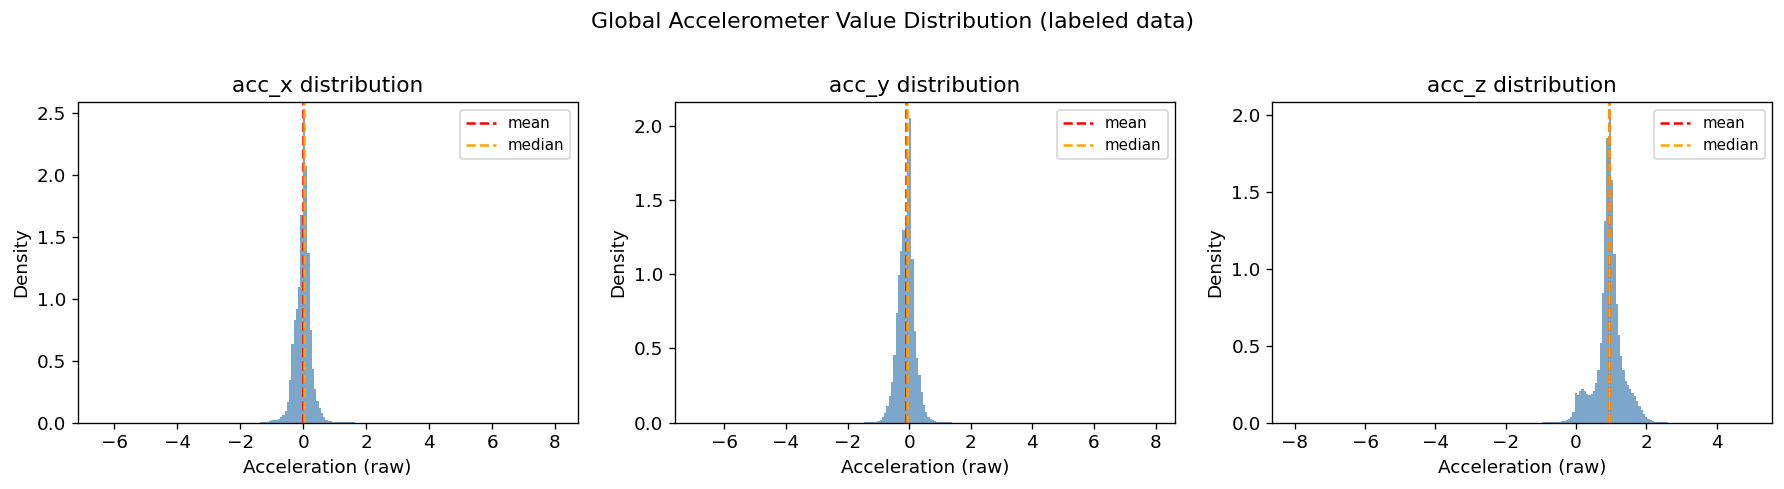

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, AXES):
    ax.hist(df_known[col].dropna(), bins=200, color='steelblue', alpha=0.7, density=True)
    ax.axvline(df_known[col].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df_known[col].median(), color='orange', linestyle='--', label='median')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel('Acceleration (raw)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Global Accelerometer Value Distribution (labeled data)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_distribution.png'), bbox_inches='tight')
plt.show()

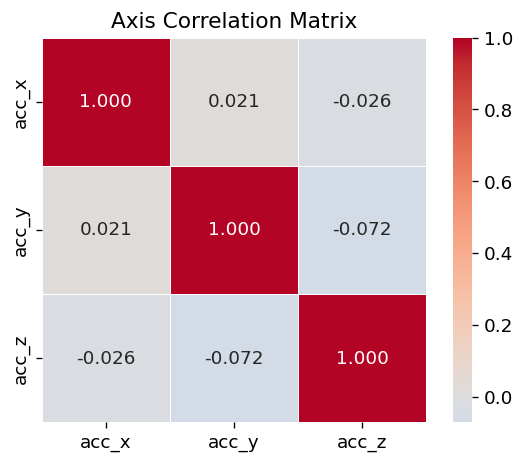

In [11]:
corr = df_known[AXES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Axis Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_correlation.png'), bbox_inches='tight')
plt.show()

## 5. Per-Class Statistics (Windowed npy)

In [12]:
rows = []
for label in labels_to_analyze:
    mask  = y == label
    x_cls = X[mask]
    for ai, axis in enumerate(AXES):
        vals = x_cls[:, ai, :].ravel()
        rows.append({
            'label': label, 'behavior': LABEL_NAMES.get(label, str(label)), 'axis': axis,
            'n_windows': int(mask.sum()), 'mean': vals.mean(), 'std': vals.std(),
            'min': vals.min(), 'max': vals.max(),
            'p25': np.percentile(vals, 25), 'p75': np.percentile(vals, 75),
            'skew': stats.skew(vals), 'kurtosis': stats.kurtosis(vals),
        })

stat_df = pd.DataFrame(rows)
pivot_stat = stat_df.pivot_table(index=['behavior','axis'],
    values=['n_windows','mean','std','min','max','p25','p75','skew','kurtosis'])
print('=== Per-class, per-axis statistics (windowed npy, normalized) ===')
print(pivot_stat.round(3).to_string())

=== Per-class, per-axis statistics (windowed npy, normalized) ===
                       kurtosis     max   mean     min  n_windows    p25    p75   skew    std
behavior        axis                                                                         
bathing         acc_x     1.177  12.069 -0.183  -9.482      521.0 -1.264  0.899 -0.115  1.851
                acc_y    16.190  28.575  0.129 -23.512      521.0 -0.664  0.937  0.346  1.676
                acc_z     7.312   6.743 -0.433 -16.193      521.0 -0.915  0.196 -1.278  1.104
body_shaking    acc_x     6.120  12.467 -1.027 -16.170        2.0 -1.683  0.381 -0.866  3.666
                acc_y    22.092  24.308  0.581 -13.532        2.0 -0.273  1.239  2.467  3.504
                acc_z     2.437   4.701 -0.261  -7.065        2.0 -0.764  0.425 -0.869  2.057
flight_cruising acc_x     7.278  31.473  0.005 -25.287    10920.0 -0.489  0.485 -0.217  0.956
                acc_y    12.420  29.716 -0.135 -25.165    10920.0 -0.798  0.461  0.363  

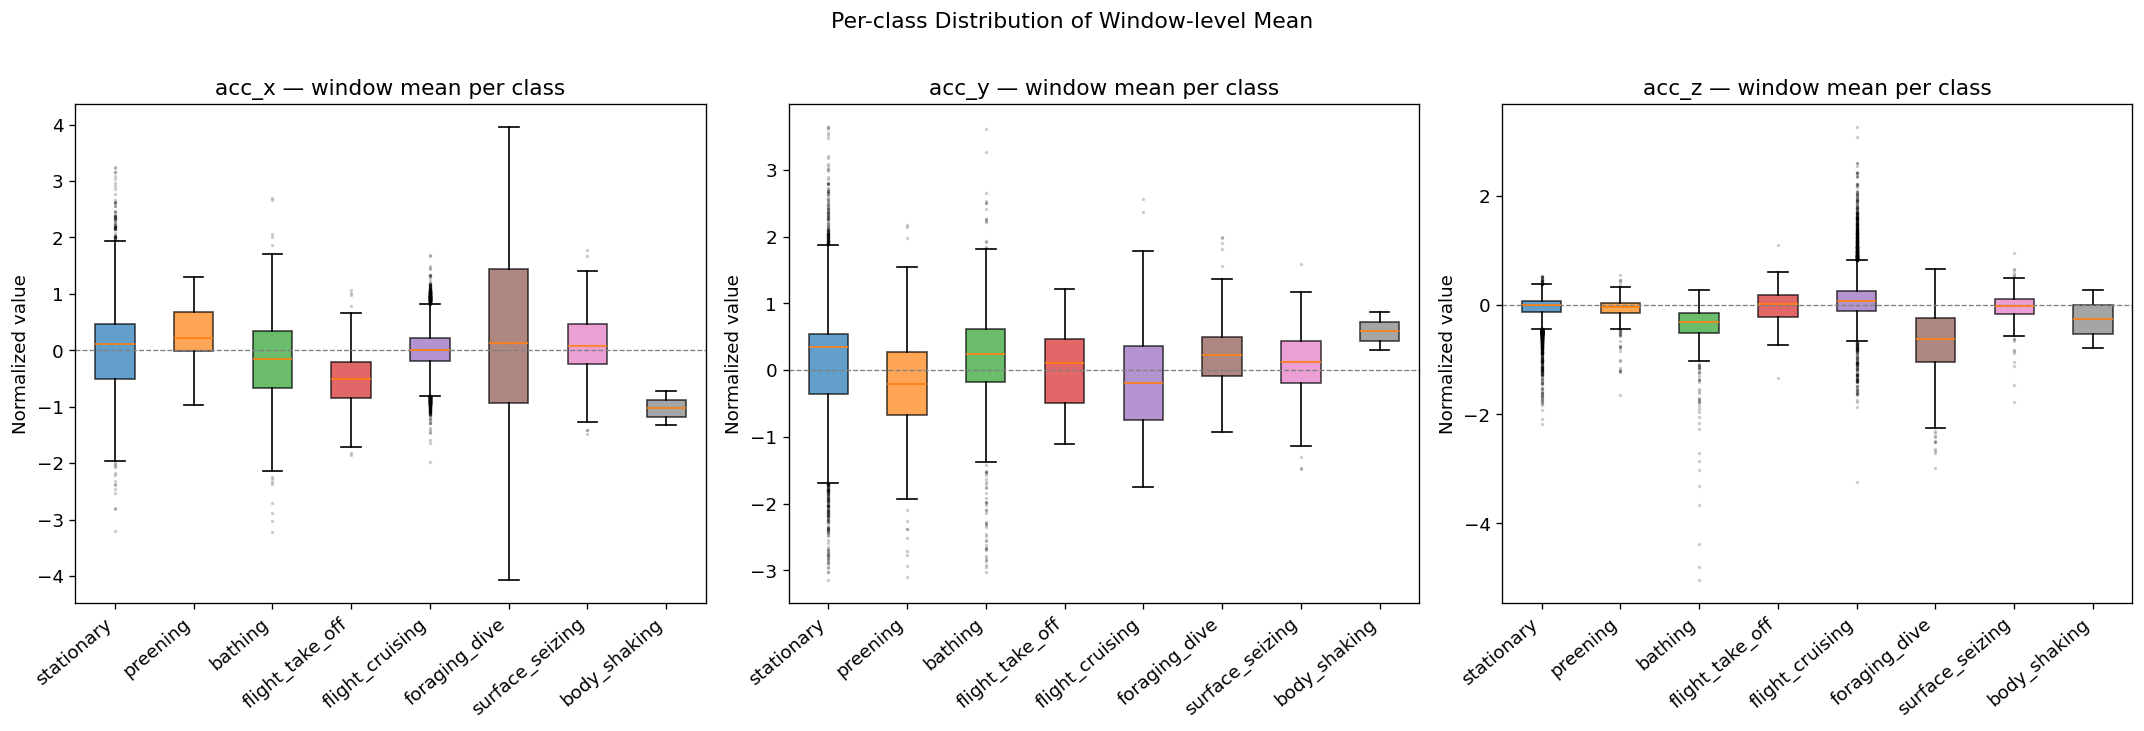

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    data_per_class = [X[y == l, ai, :].mean(axis=1) for l in labels_to_analyze]
    bp = ax.boxplot(data_per_class, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{axis} — window mean per class')
    ax.set_ylabel('Normalized value')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Per-class Distribution of Window-level Mean', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_class_boxplot.png'), bbox_inches='tight')
plt.show()

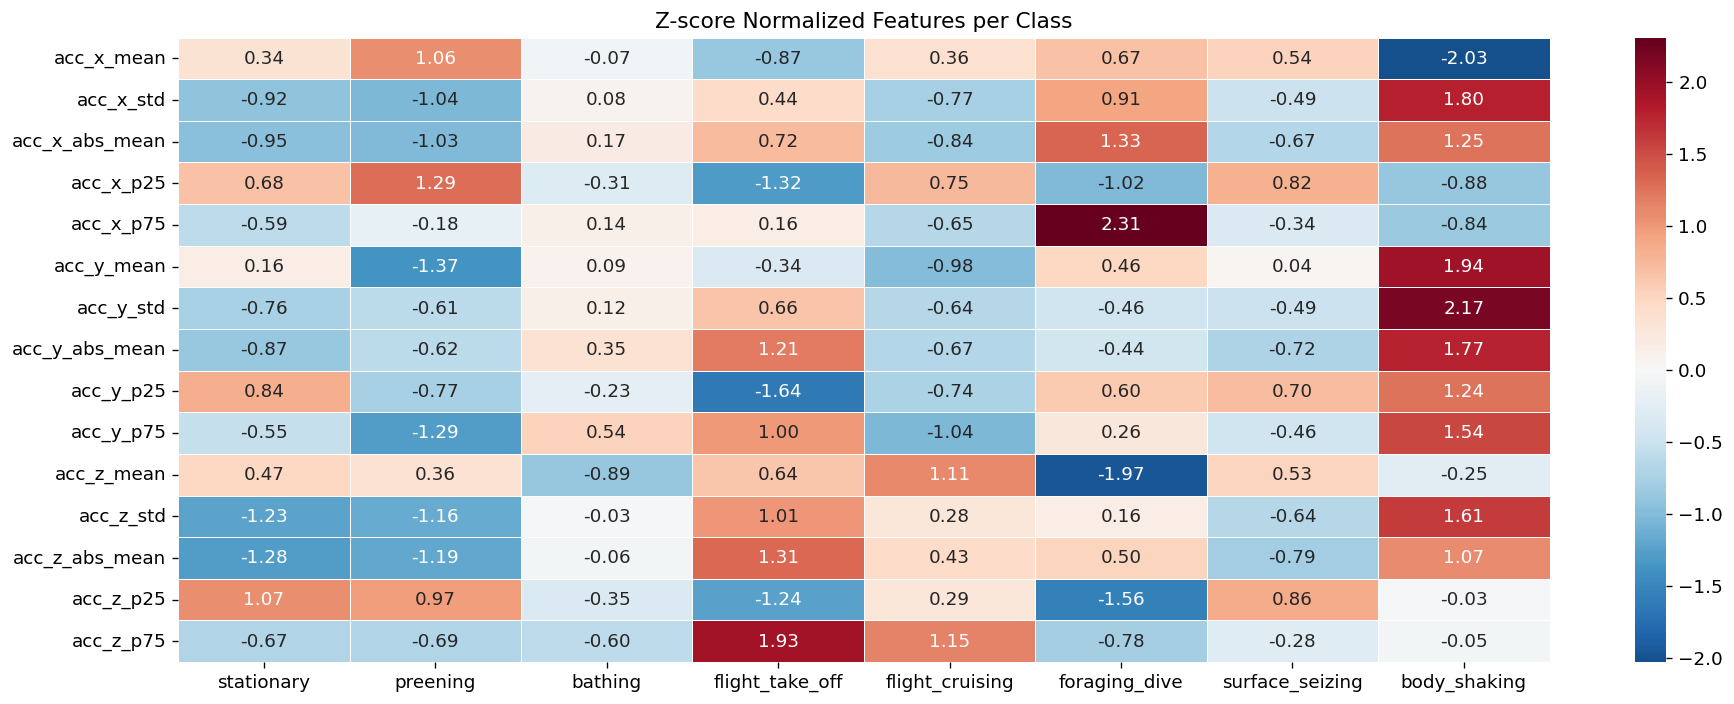

In [14]:
feat_matrix, feature_names = [], []
for label in labels_to_analyze:
    x_cls = X[y == label]
    row = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        row += [v.mean(), v.std(), np.abs(v).mean(), np.percentile(v, 25), np.percentile(v, 75)]
    feat_matrix.append(row)
for axis in AXES:
    feature_names += [f'{axis}_mean', f'{axis}_std', f'{axis}_abs_mean', f'{axis}_p25', f'{axis}_p75']

feat_df   = pd.DataFrame(feat_matrix, index=class_names, columns=feature_names)
feat_norm = (feat_df - feat_df.mean()) / (feat_df.std() + 1e-8)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(feat_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('Z-score Normalized Features per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_feature_heatmap.png'), bbox_inches='tight')
plt.show()

## 6. Signal Magnitude & Energy

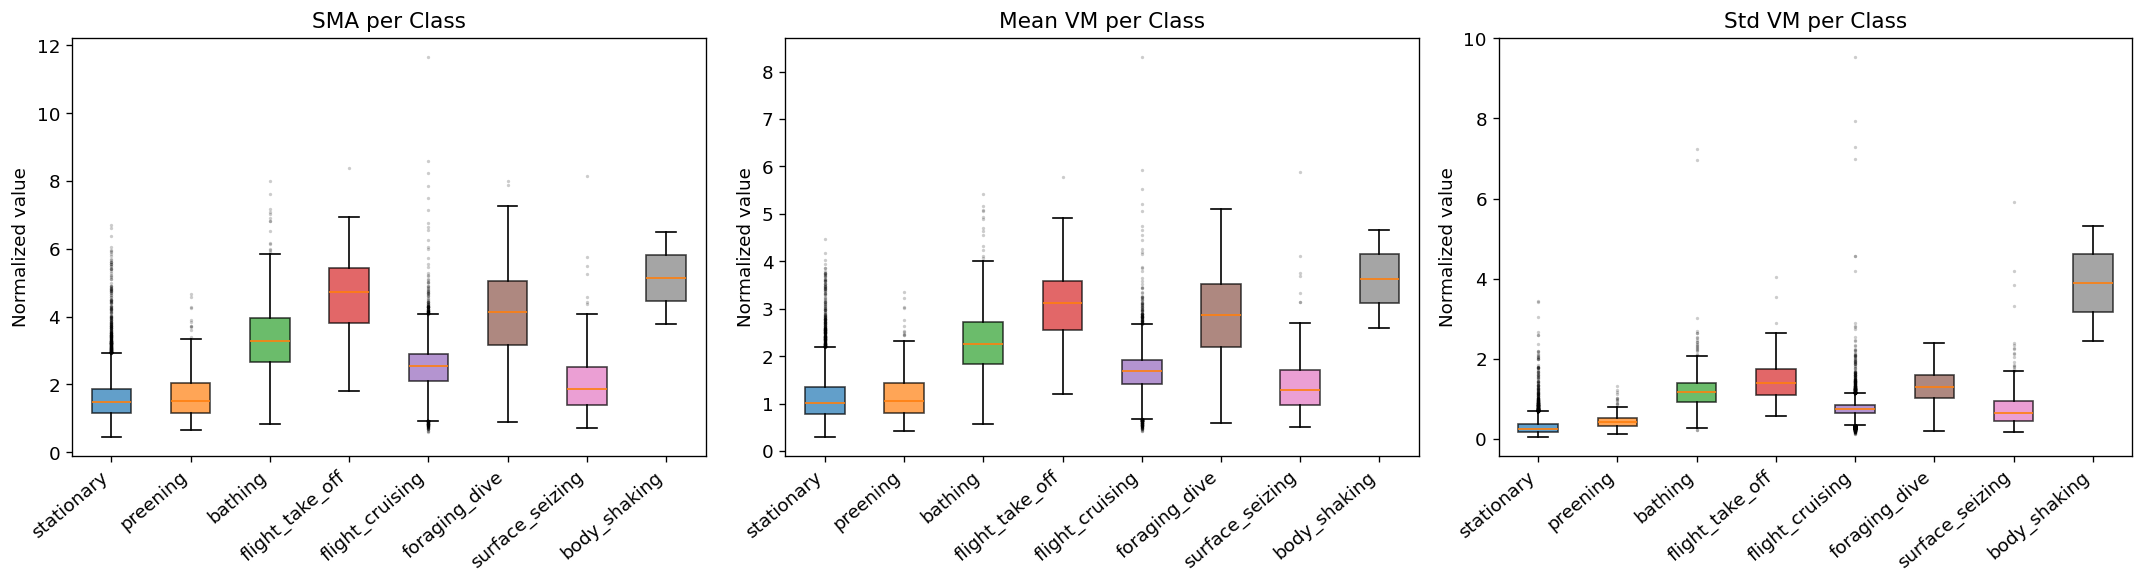

Mean SMA per class:
   0 stationary           mean=1.5997  std=0.6585
   1 preening             mean=1.6742  std=0.7134
   2 bathing              mean=3.3622  std=1.1172
   3 flight_take_off      mean=4.6615  std=1.1718
   4 flight_cruising      mean=2.4957  std=0.6537
   5 foraging_dive        mean=4.0950  std=1.4002
   6 surface_seizing      mean=2.0576  std=0.8889
   7 body_shaking         mean=5.1357  std=1.3495


In [15]:
SMA = np.abs(X).sum(axis=1).mean(axis=1)
VM_mean = np.sqrt((X**2).sum(axis=1)).mean(axis=1)
VM_std  = np.sqrt((X**2).sum(axis=1)).std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, [SMA, VM_mean, VM_std], ['SMA', 'Mean VM', 'Std VM']):
    data_cls = [metric[y == l] for l in labels_to_analyze]
    bp = ax.boxplot(data_cls, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{title} per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Normalized value')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'magnitude_energy.png'), bbox_inches='tight')
plt.show()

print('Mean SMA per class:')
for l, d in zip(labels_to_analyze, [SMA[y==l] for l in labels_to_analyze]):
    print(f'  {l:2d} {LABEL_NAMES.get(l,"?"):<20} mean={d.mean():.4f}  std={d.std():.4f}')

## 7. Frequency Domain Analysis

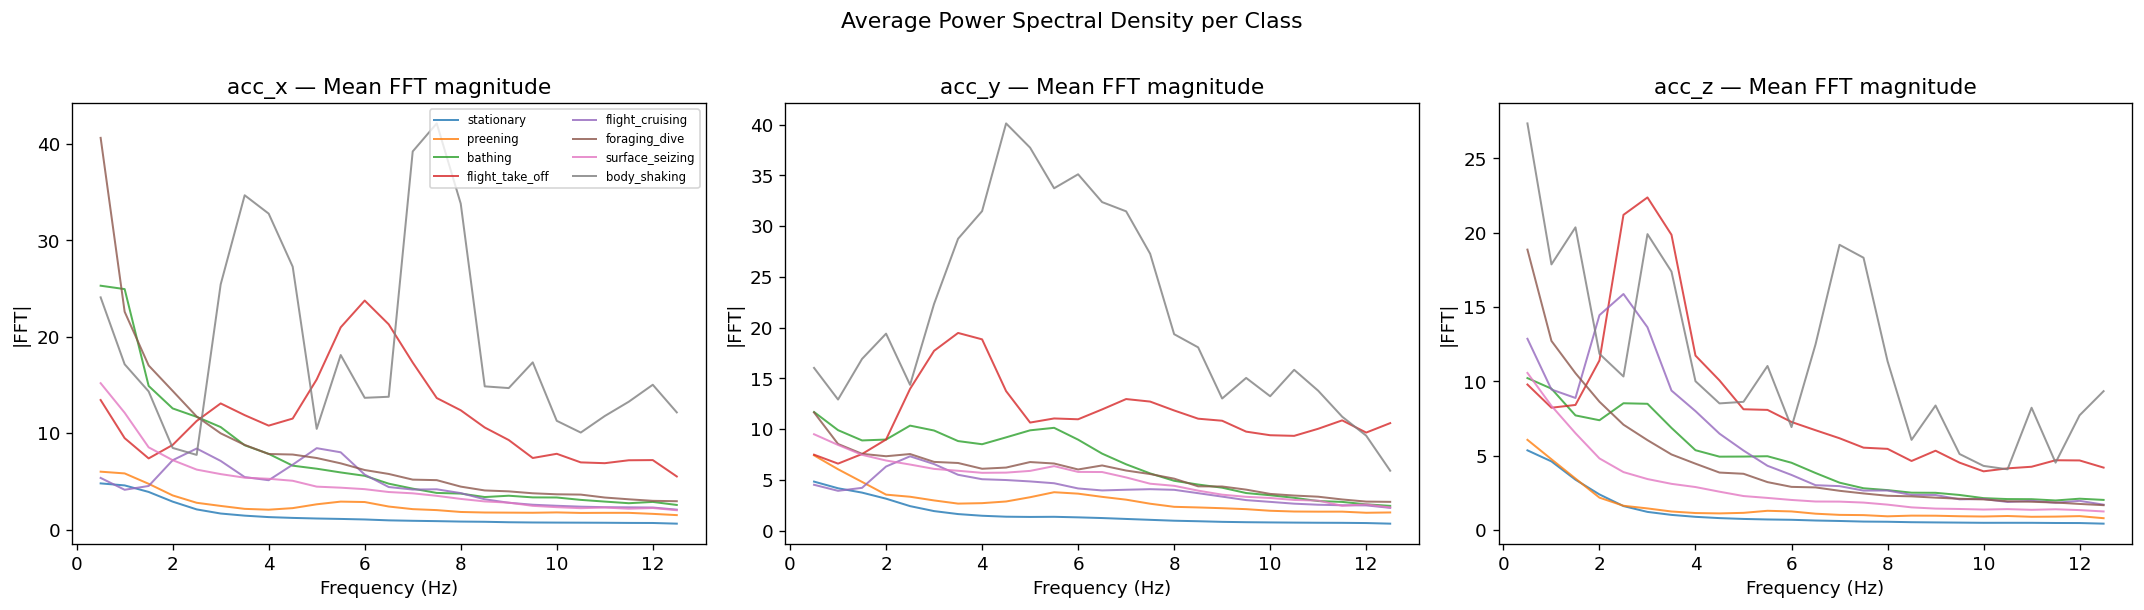

In [16]:
T     = X.shape[2]
freqs = np.fft.rfftfreq(T, d=1.0/SAMPLE_RATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    for li, label in enumerate(labels_to_analyze):
        x_cls   = X[y == label, ai, :]
        fft_mag = np.abs(np.fft.rfft(x_cls, axis=1)).mean(axis=0)
        ax.plot(freqs[1:], fft_mag[1:], label=LABEL_NAMES.get(label, str(label)),
                color=COLORS[li], alpha=0.8, linewidth=1.2)
    ax.set_title(f'{axis} — Mean FFT magnitude')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT|')
    if ai == 0:
        ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.suptitle('Average Power Spectral Density per Class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'psd_per_class.png'), bbox_inches='tight')
plt.show()

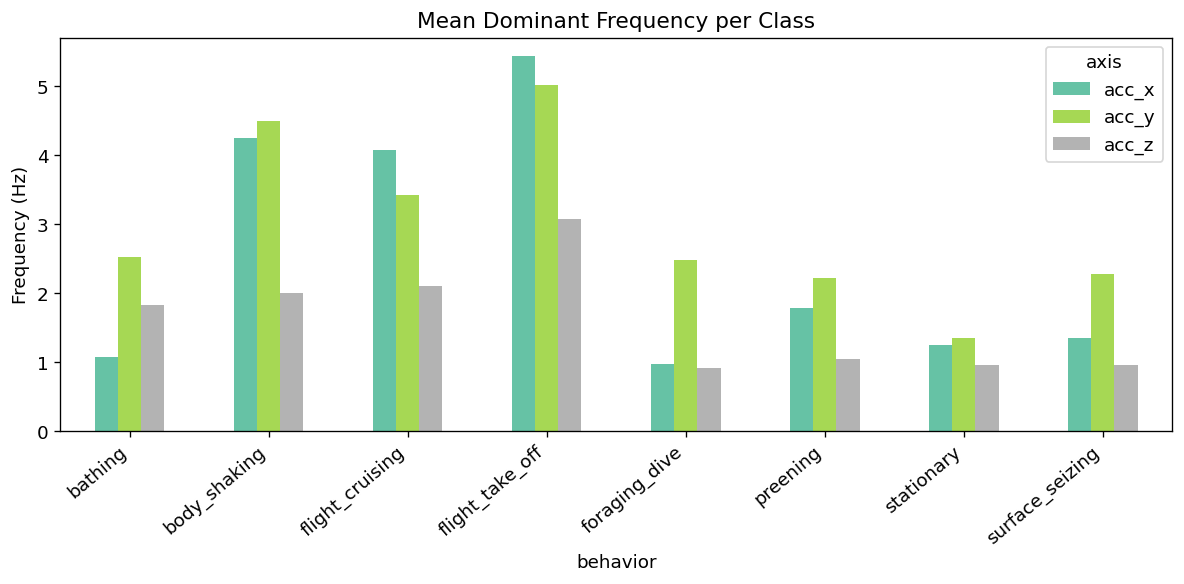

axis             acc_x  acc_y  acc_z
behavior                            
bathing          1.078  2.526  1.826
body_shaking     4.250  4.500  2.000
flight_cruising  4.083  3.433  2.106
flight_take_off  5.437  5.018  3.077
foraging_dive    0.976  2.485  0.910
preening         1.784  2.223  1.042
stationary       1.256  1.351  0.955
surface_seizing  1.359  2.281  0.967


In [17]:
rows_dom = []
for label in labels_to_analyze:
    for ai, axis in enumerate(AXES):
        x_cls    = X[y == label, ai, :]
        fft_mag  = np.abs(np.fft.rfft(x_cls, axis=1))[:, 1:]
        dom_freq = freqs[1:][fft_mag.argmax(axis=1)]
        rows_dom.append({'behavior': LABEL_NAMES.get(label, str(label)), 'axis': axis,
                         'mean_dom_freq': dom_freq.mean(), 'std_dom_freq': dom_freq.std()})

pivot_dom = pd.DataFrame(rows_dom).pivot(index='behavior', columns='axis', values='mean_dom_freq')
fig, ax = plt.subplots(figsize=(10, 5))
pivot_dom.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Mean Dominant Frequency per Class')
ax.set_ylabel('Frequency (Hz)')
ax.set_xticklabels(pivot_dom.index, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dominant_freq.png'), bbox_inches='tight')
plt.show()
print(pivot_dom.round(3).to_string())

## 8. Average Window Shape per Class

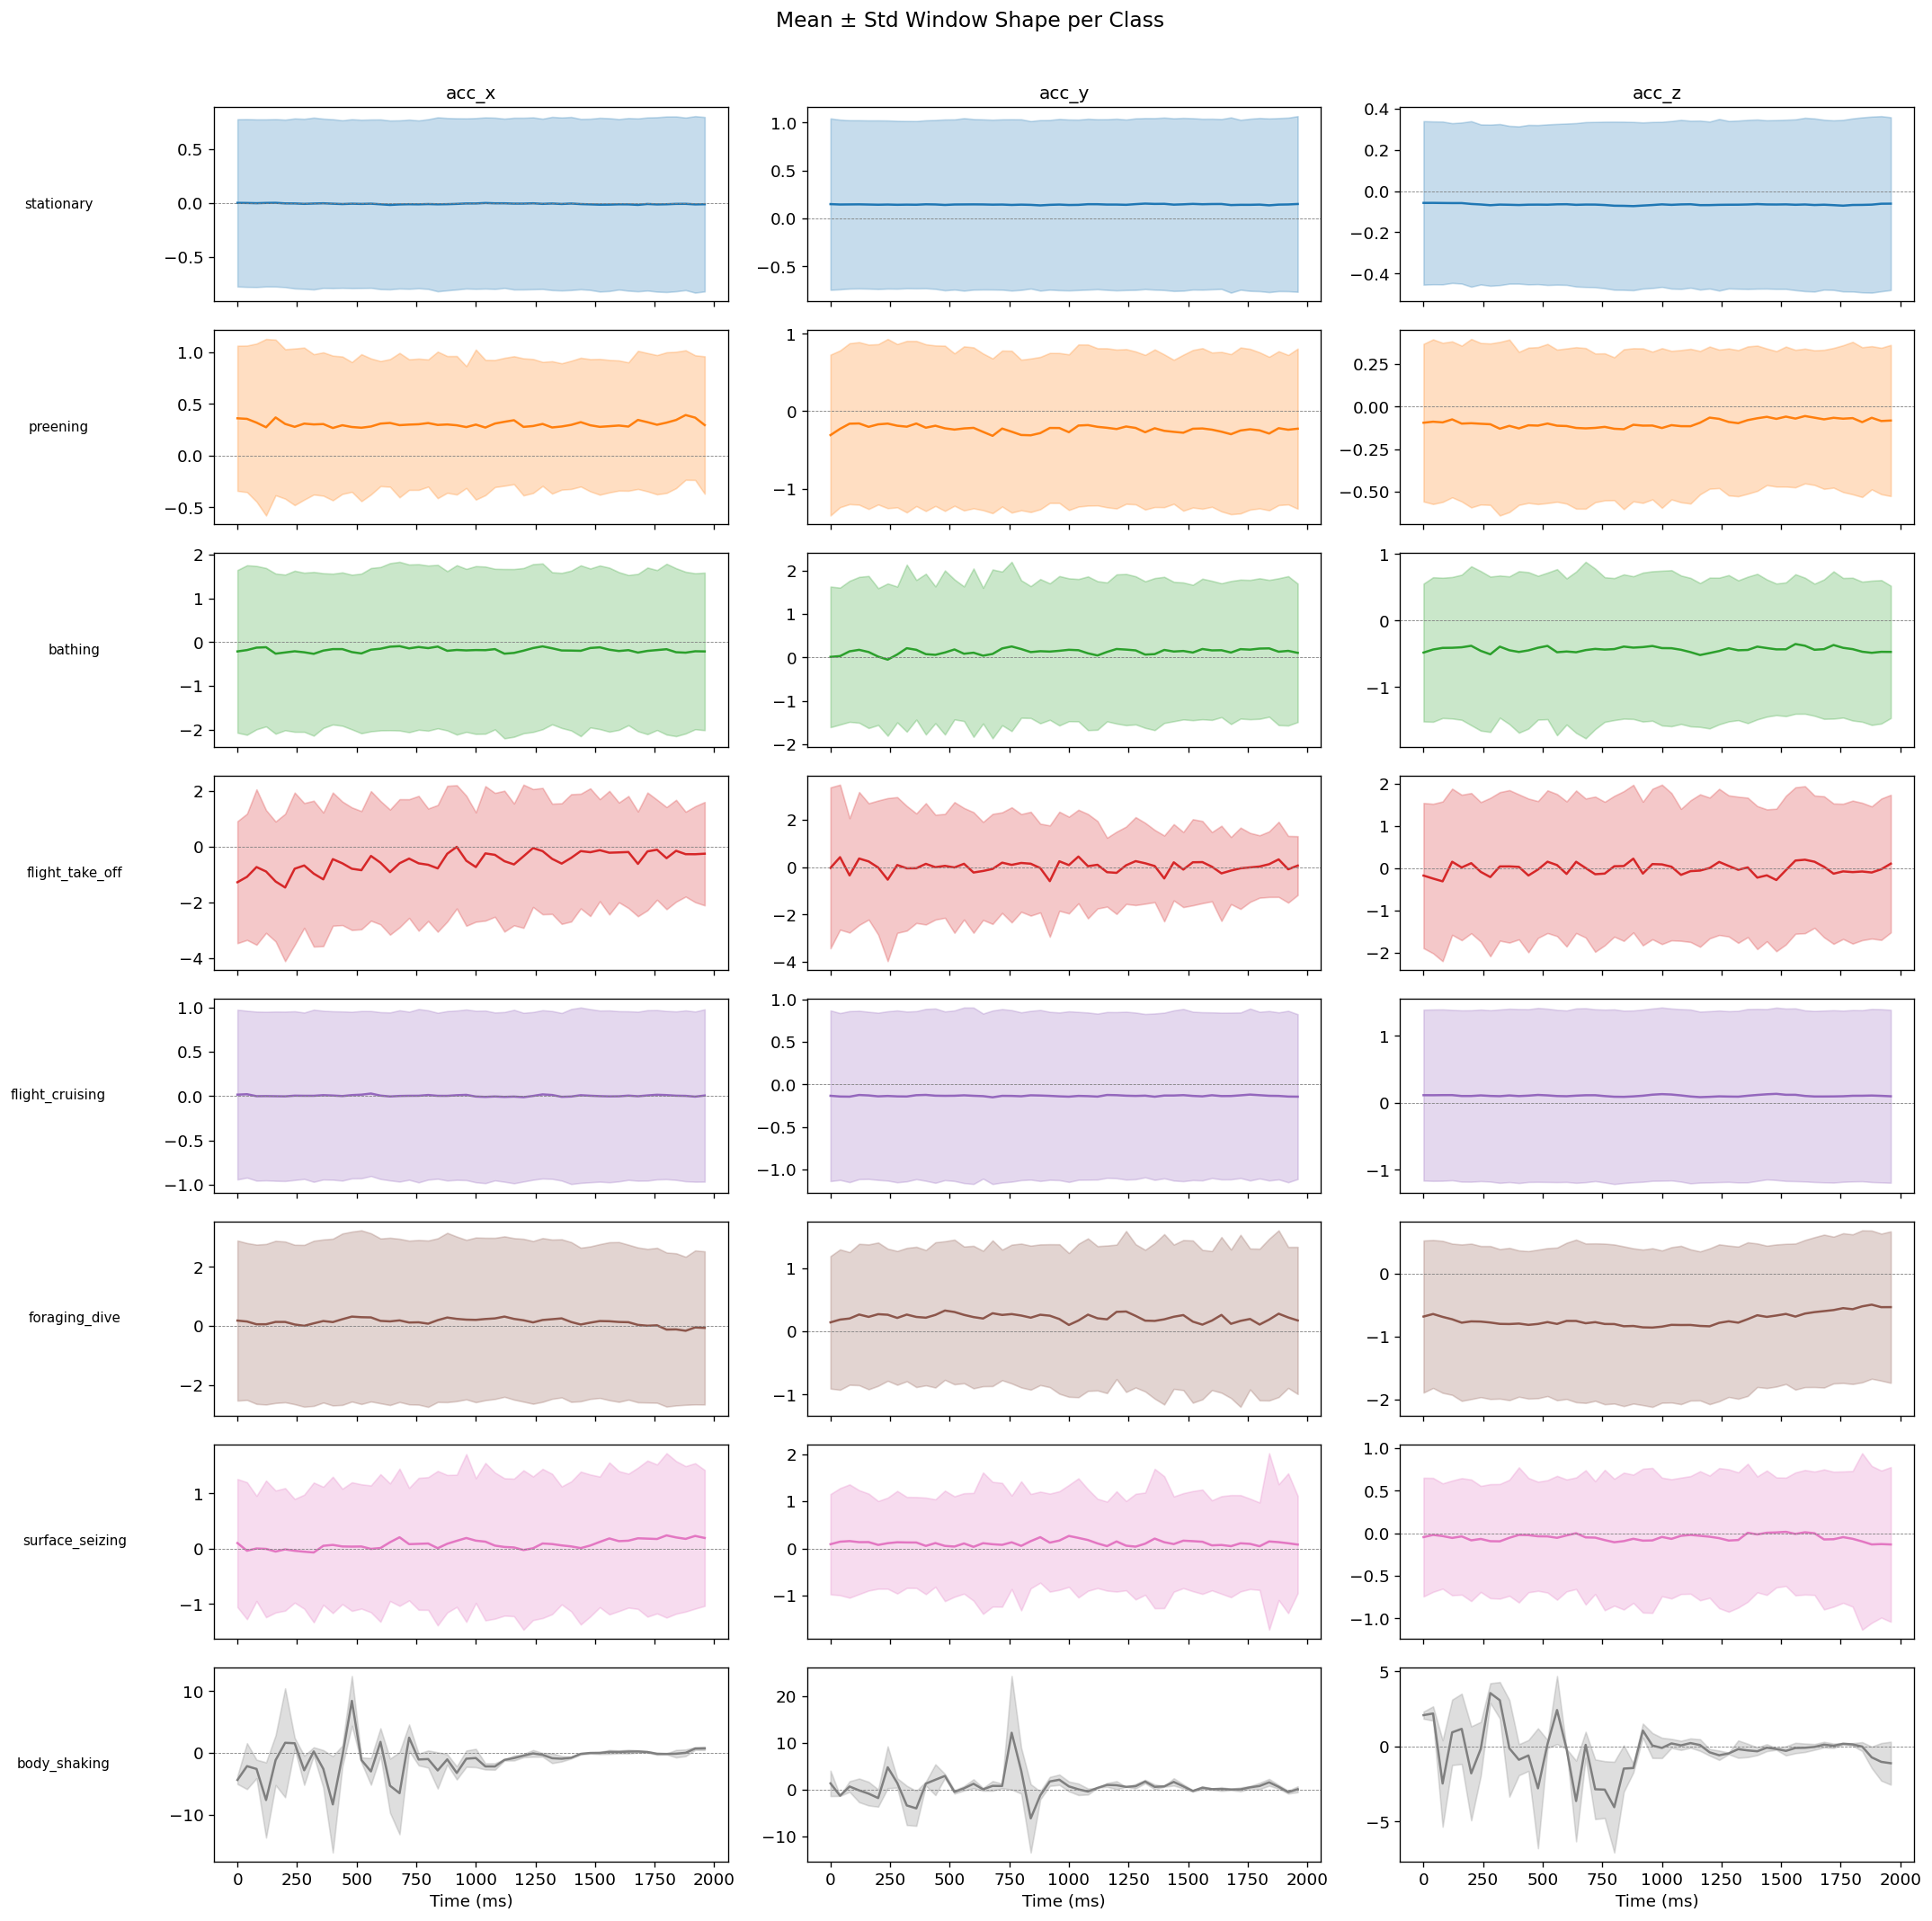

In [18]:
n_cls = len(labels_to_analyze)
fig, axes = plt.subplots(n_cls, 3, figsize=(18, 2.2 * n_cls), sharex=True)
t = np.arange(T) / SAMPLE_RATE * 1000

for row, label in enumerate(labels_to_analyze):
    x_cls = X[y == label]
    for ai, axis in enumerate(AXES):
        ax = axes[row, ai]
        mu = x_cls[:, ai, :].mean(axis=0)
        sd = x_cls[:, ai, :].std(axis=0)
        ax.plot(t, mu, color=COLORS[row], linewidth=1.5)
        ax.fill_between(t, mu - sd, mu + sd, alpha=0.25, color=COLORS[row])
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        if row == 0:
            ax.set_title(axis, fontsize=12)
        if ai == 0:
            ax.set_ylabel(LABEL_NAMES.get(label, str(label)), fontsize=9,
                          rotation=0, labelpad=70, va='center')
        if row == n_cls - 1:
            ax.set_xlabel('Time (ms)')

plt.suptitle('Mean ± Std Window Shape per Class', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_window_per_class.png'), bbox_inches='tight')
plt.show()

## 9. Between-Class Separability

In [19]:
print('=== Kruskal-Wallis H-test ===')
for ai, axis in enumerate(AXES):
    groups = [X[y == l, ai, :].ravel() for l in labels_to_analyze]
    h, pv  = kruskal(*groups)
    print(f'  {axis}: H={h:.2f}, p={pv:.2e}  → {"SIGNIFICANT" if pv < 0.05 else "not significant"}')

=== Kruskal-Wallis H-test ===
  acc_x: H=2677.42, p=0.00e+00  → SIGNIFICANT
  acc_y: H=32066.55, p=0.00e+00  → SIGNIFICANT
  acc_z: H=46494.05, p=0.00e+00  → SIGNIFICANT


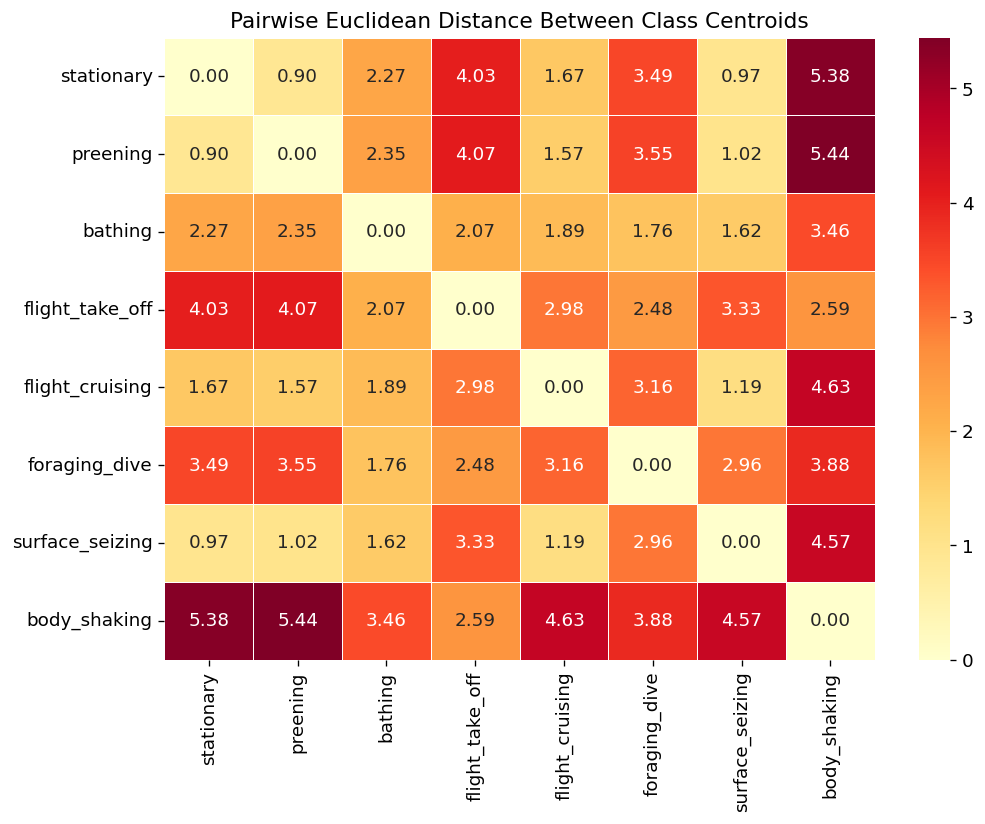

In [20]:
def class_centroid(x_cls):
    feats = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        feats += [v.mean(axis=1).mean(), v.std(axis=1).mean(),
                  np.percentile(v, 25), np.percentile(v, 75), np.abs(v).mean()]
    return np.array(feats)

centroids = np.array([class_centroid(X[y == l]) for l in labels_to_analyze])
dist_mat  = pairwise_distances(centroids)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.3)
ax.set_title('Pairwise Euclidean Distance Between Class Centroids')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pairwise_class_distance.png'), bbox_inches='tight')
plt.show()

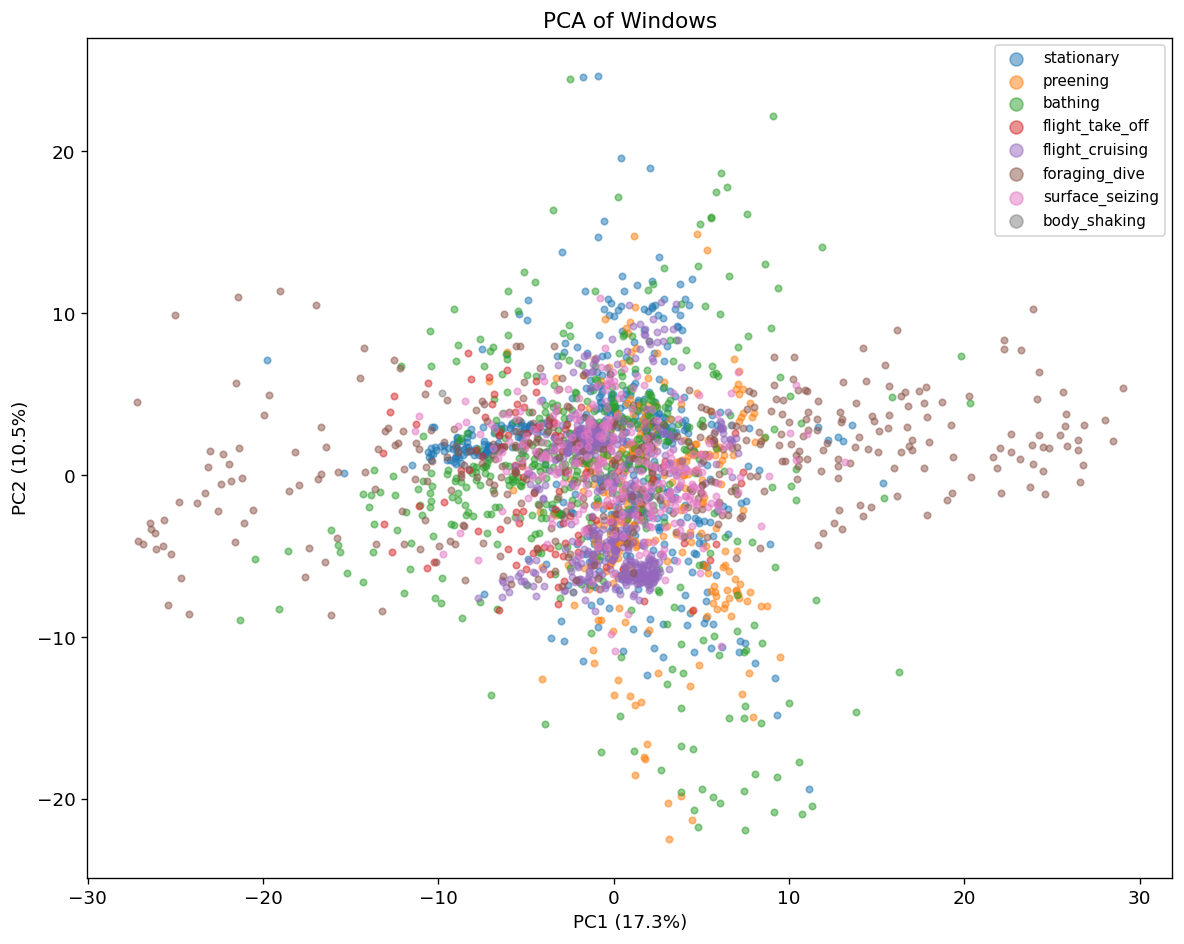

Variance explained PC1+PC2: 27.8%


In [21]:
N_PER_CLASS = 500
idx_all = []
for label in labels_to_analyze:
    idx_l  = np.where(y == label)[0]
    n_take = min(N_PER_CLASS, len(idx_l))
    idx_all.append(np.random.choice(idx_l, n_take, replace=False))
idx_all = np.concatenate(idx_all)

X_flat  = X[idx_all].reshape(len(idx_all), -1)
y_sub   = y[idx_all]

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(10, 8))
for li, label in enumerate(labels_to_analyze):
    mask = y_sub == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[COLORS[li]],
               label=LABEL_NAMES.get(label, str(label)), alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Windows')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_visualization.png'), bbox_inches='tight')
plt.show()
print(f'Variance explained PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

## 10. Axis Cross-Correlation per Class

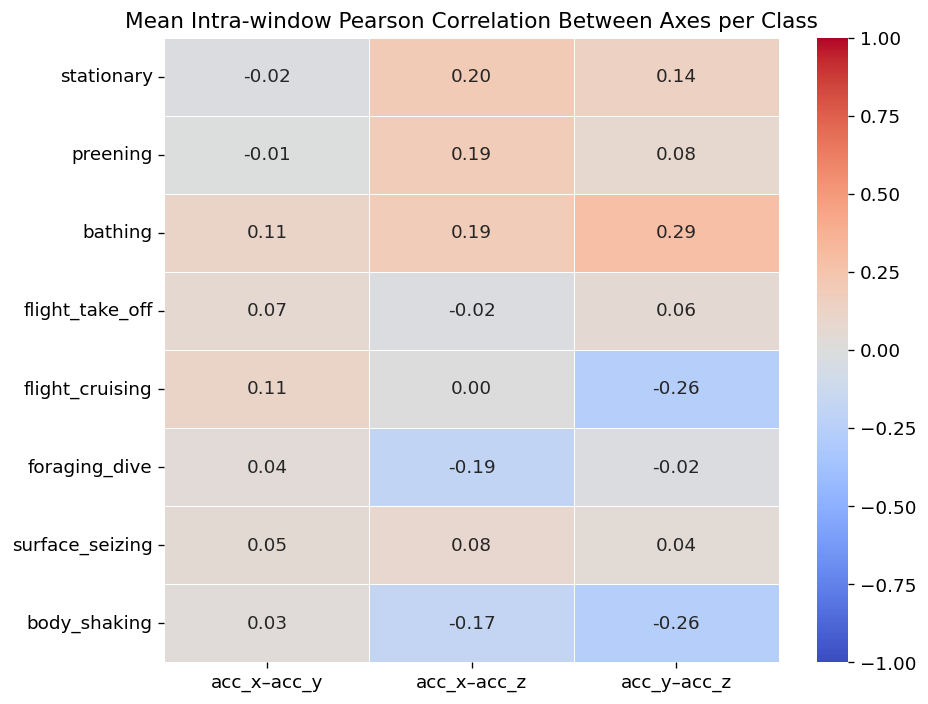

In [22]:
axis_pairs = [('acc_x','acc_y',0,1), ('acc_x','acc_z',0,2), ('acc_y','acc_z',1,2)]
corr_data  = {f'{a}–{b}': [] for a, b, _, __ in axis_pairs}

for label in labels_to_analyze:
    x_cls = X[y == label]
    for a_name, b_name, ai, bi in axis_pairs:
        r_vals = [np.corrcoef(x_cls[n, ai], x_cls[n, bi])[0, 1] for n in range(len(x_cls))]
        corr_data[f'{a_name}–{b_name}'].append(np.nanmean(r_vals))

corr_df = pd.DataFrame(corr_data, index=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Mean Intra-window Pearson Correlation Between Axes per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_xcorr_per_class.png'), bbox_inches='tight')
plt.show()

## 11. Window Quality & Label Consistency

In [23]:
y_all    = Y.astype(int)
all_same = (y_all == y_all[:, [0]]).all(axis=1)
print(f'Windows with 100% consistent labels : {all_same.sum():,} / {len(all_same):,} ({all_same.mean()*100:.1f}%)')
print(f'Windows with mixed labels           : {(~all_same).sum():,} ({(~all_same).mean()*100:.1f}%)')
print(f'Window size : {T} timesteps = {T/SAMPLE_RATE*1000:.0f} ms at {SAMPLE_RATE} Hz')
print(f'Total windows : {len(X):,}')
for ai, axis in enumerate(AXES):
    v = X[:, ai, :]
    print(f'{axis}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.6f}  std={v.std():.6f}')

Windows with 100% consistent labels : 21,292 / 21,868 (97.4%)
Windows with mixed labels           : 576 (2.6%)
Window size : 50 timesteps = 2000 ms at 25 Hz
Total windows : 21,868
acc_x: min=-25.2874  max=31.4726  mean=-0.000000  std=1.000000
acc_y: min=-25.1645  max=29.7157  mean=0.000001  std=1.000000
acc_z: min=-22.7143  max=10.1789  mean=-0.000001  std=1.000000


## 12. Additional Sensor Analysis (Pressure & GPS)

=== Pressure sensor statistics ===
count    247661.0000
mean       1006.6358
std           8.9491
min         961.9000
25%        1000.6000
50%        1004.8000
75%        1012.5000
max        1038.0000


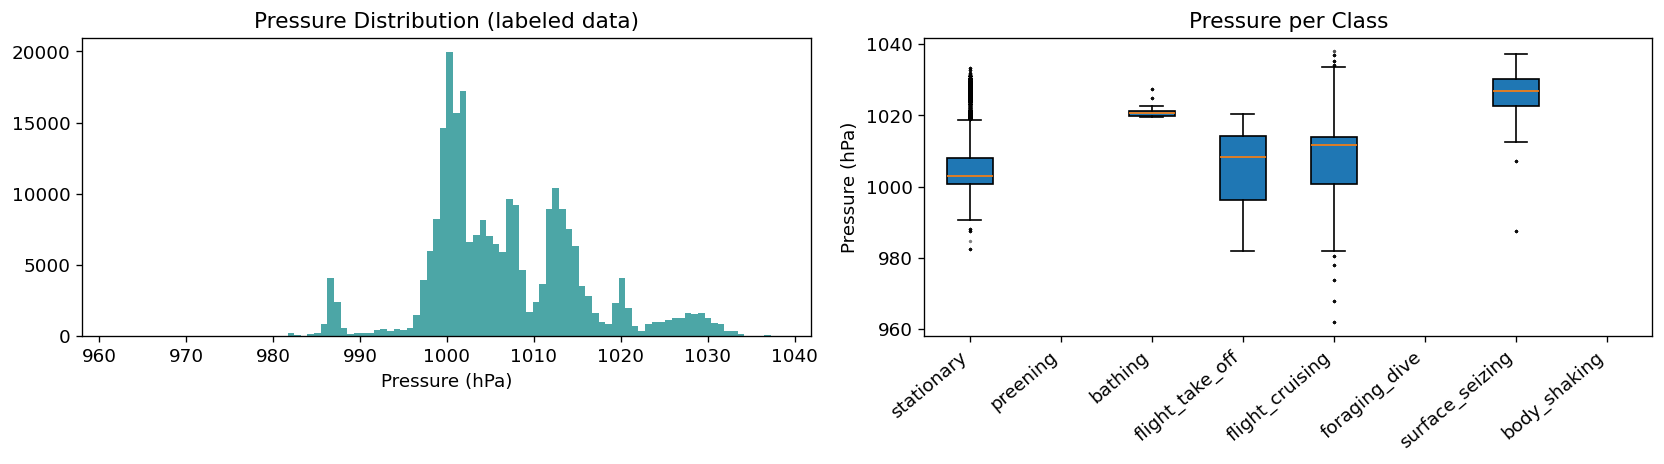

In [24]:
# Pressure per class (if available)
if 'pressure' in df_known.columns:
    print('=== Pressure sensor statistics ===')
    print(df_known['pressure'].describe().round(4).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    ax.hist(df_known['pressure'].dropna(), bins=100, color='teal', alpha=0.7)
    ax.set_title('Pressure Distribution (labeled data)')
    ax.set_xlabel('Pressure (hPa)')

    ax = axes[1]
    cls_press = [df_known[df_known['label_id'] == l]['pressure'].dropna().values
                 for l in labels_to_analyze]
    ax.boxplot(cls_press, labels=class_names, patch_artist=True,
               flierprops=dict(marker='.', alpha=0.1, markersize=2))
    ax.set_title('Pressure per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Pressure (hPa)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'pressure_analysis.png'), bbox_inches='tight')
    plt.show()
else:
    print('No pressure column in data.')

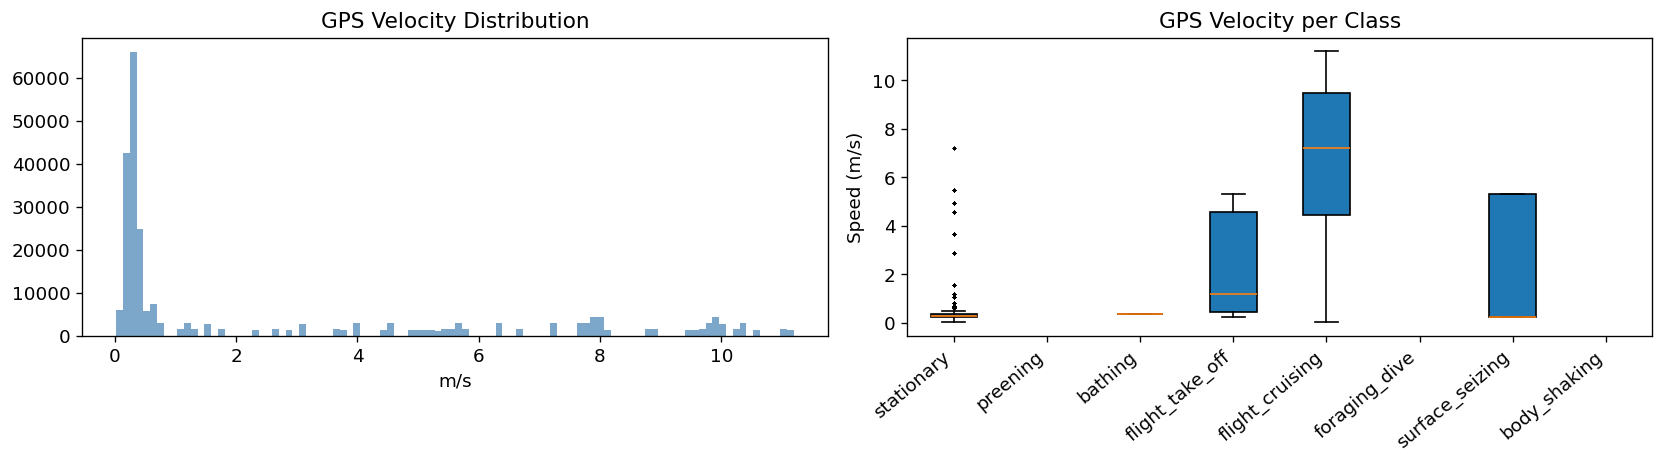

In [25]:
# GPS velocity per class
if 'GPS_velocity' in df_known.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    ax.hist(df_known['GPS_velocity'].dropna(), bins=100, color='steelblue', alpha=0.7)
    ax.set_title('GPS Velocity Distribution')
    ax.set_xlabel('m/s')

    ax = axes[1]
    gps_cls = [df_known[df_known['label_id'] == l]['GPS_velocity'].dropna().values
               for l in labels_to_analyze]
    ax.boxplot(gps_cls, labels=class_names, patch_artist=True,
               flierprops=dict(marker='.', alpha=0.1, markersize=2))
    ax.set_title('GPS Velocity per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Speed (m/s)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'gps_analysis.png'), bbox_inches='tight')
    plt.show()

## 13. Summary Table

In [26]:
summary_rows = []
for label, pi in zip(labels_to_analyze, p):
    mask    = y == label
    x_cls   = X[mask]
    sma_val = np.abs(x_cls).sum(axis=1).mean(axis=1).mean()
    vm_val  = np.sqrt((x_cls**2).sum(axis=1)).mean(axis=1).mean()
    row = {
        'label': label, 'behavior': LABEL_NAMES.get(label, str(label)),
        'n_windows': int(mask.sum()), 'prop_%': round(pi * 100, 2),
        'inv_freq_weight': round((1/pi) / sum(1/q for q in p), 4),
        'SMA_mean': round(float(sma_val), 4), 'VM_mean': round(float(vm_val), 4),
    }
    for ai, axis in enumerate(AXES):
        v = x_cls[:, ai, :]
        row[f'{axis}_mean'] = round(float(v.mean()), 4)
        row[f'{axis}_std']  = round(float(v.std()),  4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('label')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print('=== Summary for Model Training ===')
print(summary_df.to_string())

=== Summary for Model Training ===
              behavior  n_windows  prop_%  inv_freq_weight  SMA_mean  VM_mean  acc_x_mean  acc_x_std  acc_y_mean  acc_y_std  acc_z_mean  acc_z_std
label                                                                                                                                             
0           stationary       9305   42.55           0.0002    1.5997   1.1151     -0.0072     0.7921      0.1447     0.8905     -0.0656     0.4045
1             preening        301    1.38           0.0064    1.6742   1.1599      0.3069     0.6674     -0.2304     1.0211     -0.0960     0.4457
2              bathing        521    2.38           0.0037    3.3622   2.3112     -0.1826     1.8510      0.1286     1.6761     -0.4325     1.1042
3      flight_take_off        111    0.51           0.0173    4.6615   3.1085     -0.5279     2.2305      0.0223     2.1579     -0.0200     1.7116
4      flight_cruising      10920   49.94           0.0002    2.4957   1.6704      